# Random Fourier Signature Features (RFSF)

An unbiased, finite-dimensional approximation to the signature kernel ([Tóth et al., 2023](https://arxiv.org/pdf/2311.12214.pdf), Alg. 2 & 3): Random Fourier Features for the static kernel + a tensorized random projection (RFSF-TRP). Scales **linearly** in the number of sequences, so it is the way to run the signature kernel on large $N$.

## Environment
Detect the live backend/device and whether a SYCL fast-path is available.

In [1]:
import sys, pathlib
# Make `_nbtools` and the in-repo `ksig` importable whether the notebook is
# launched from ./notebooks or from the repo root (no `pip install` needed).
_nbdir = pathlib.Path.cwd()
_root = _nbdir.parent if (_nbdir / "_nbtools.py").exists() else _nbdir
_nbdir = _root / "notebooks"
for _p in (str(_nbdir), str(_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import ksig
import _nbtools as nb
%matplotlib inline

ENV = nb.detect_env()
nb.print_env_banner(ENV)

[2026-06-02 01:18:13,379] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to xpu (auto detect)


icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
/usr/bin/ld: /var/tmp/pbs.8519295.aurora-pbs-0001.hostmgmt.cm.aurora.alcf.anl.gov/claude-35813/tmpt4x0warv/test.o: in function `main':
test.c:(.text+0x25): undefined reference to `io_pgetevents'
icx: error: linker command failed with exit code 1 (use -v to see invocation)


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-02 01:18:18,178] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


ksig backend : torch  |  device: xpu  |  SYCL: available  |  ksig unknown


## Deterministic input
`simulate(24, 20, 3, seed=0)` — integrated random walks (the NumPy RNG is identical on every machine).

In [2]:
X = nb.simulate(24, 20, 3, seed=0)
print('X shape:', X.shape, '| dtype:', X.dtype)

X shape: (24, 20, 3) | dtype: float64


## Compute the feature map

**Reference output — NVIDIA H100 NVL (CuPy 14.1.0), kwargs: `n_levels=4, RFF(n_components=100), TRP(rank=1), normalize=True`:**

```text
gram shape   : (24, 24)
feature shape: (24, 401)
diag mean    : 1.0
rel err vs exact: 0.1323
```

> ⚠️ **Portability:** these feature maps are **random**. `diag == 1` (from
> `normalize=True`) and the Gram's symmetry are exact on any backend, but the
> *element values* and the exact `rel err` depend on the RNG stream, which
> differs between CuPy and torch. Expect the **same ballpark** rel-err, and the
> same **convergence** — it shrinks as `n_components` grows:
> `50:0.1891  100:0.1323  250:0.0821  500:0.0582` (n_components:rel_err, on NVIDIA H100 NVL).

In [3]:
N_COMPONENTS = 100                   # the value the reference was frozen at
k = ksig.kernels.SignatureFeatures(n_levels=4, order=1, normalize=True, static_features=ksig.static.features.RandomFourierFeatures(n_components=N_COMPONENTS, random_state=0), projection=ksig.projections.TensorizedRandomProjection(n_components=N_COMPONENTS, rank=1, random_state=0))
k.fit(X)
K = nb.as_host(k(X)); P = nb.as_host(k.transform(X))
exact = ksig.kernels.SignatureKernel(n_levels=4, order=1, normalize=True,
                                     static_kernel=ksig.static.kernels.RBFKernel())
Kex = nb.as_host(exact(X))
rel = float(np.linalg.norm(K - Kex) / np.linalg.norm(Kex))
print("gram shape   :", tuple(K.shape))
print("feature shape:", tuple(P.shape))
print("diag mean    :", round(float(np.diag(K).mean()), 6))
print("rel err vs exact:", round(rel, 4))

gram shape   : (24, 24)
feature shape: (24, 401)
diag mean    : 1.0
rel err vs exact: 0.1294


## Scaling — green = CUDA reference, blue = this machine

The cell below sweeps **n_samples N  (L=50, d=5, n_components=100)** and times each point on whatever backend
is live, then overlays:

* 🟩 **green** — the frozen reference measured on **NVIDIA H100 NVL** (`cuda_reference.json`),
* 🟦 **blue** — what *this* machine computes now (torch-native on Aurora XPU / CUDA / CPU),
> This kernel has **no SYCL fast-path** — only SigPDE / GAK / RWS dispatch to
> `ksig._sycl` — so there is no orange curve here, just green vs blue.

The grid and the knobs at the top of the cell are **tunable** — they default to
the reference grid so blue lines up with green; widen them to push the frontier.

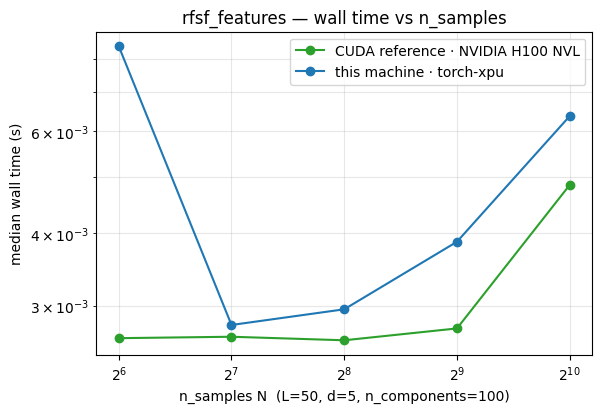

In [4]:
# --- tunable knobs (default to the CUDA-reference grid) ---------------------
N_GRID = [64, 128, 256, 512, 1024]     # sample counts to sweep (feature methods scale ~linearly)
L, D   = 50, 5                  # fixed sequence length / channels
REPS   = 5
N_COMPONENTS = 100                # more components -> tighter approximation

def time_one(N):
    Xs = nb.simulate(N, L, D, seed=1)
    k = ksig.kernels.SignatureFeatures(n_levels=4, order=1, normalize=True, static_features=ksig.static.features.RandomFourierFeatures(n_components=N_COMPONENTS, random_state=0), projection=ksig.projections.TensorizedRandomProjection(n_components=N_COMPONENTS, rank=1, random_state=0))
    k.fit(Xs)
    return nb.timeit(lambda: k(Xs), reps=REPS, device=ENV["device"])

# This kernel has no SYCL fast-path (only SigPDE / GAK / RWS dispatch to
# ksig._sycl), so there is no orange curve -- just green vs blue.
times = [time_one(N) for N in N_GRID]
nb.scaling_plot(N_GRID, times, "rfsf_features", title="rfsf_features — wall time vs n_samples");